# Chapter 6, Quantum Mechanics in One Dimension

Operators, eigenfunctions/eigenvalues, sharp vs. fuzzy observables, the
particle in a box, the harmonic oscillator ground state, and a full
nonstationary-state problem (Problem 37) -- each one derived in SymPy, not
quoted, with a torch cross-check where a numeric loop adds something.


In [1]:
from IPython.display import display
import sympy as sp
sp.init_printing()
import torch
import numpy as np

x, t, L, m, omega, hbar, k = sp.symbols("x t L m omega hbar k", positive=True)
n = sp.Symbol("n", positive=True, integer=True)
print("SymPy", sp.__version__, "| torch", torch.__version__)


SymPy 1.14.0 | torch 2.11.0+cu128


## Example 6.16 -- Plane waves are sharp observables for momentum AND energy

$\Psi_k(x,t) = e^{i(kx-\omega t)}$. Apply the momentum, kinetic-energy, and
energy operators directly (Table 6.2) and check each returns the SAME
function times a constant (the eigenvalue condition) -- and that the two
routes to the energy (via $[E]$ and via $[H]$) agree, which is the
dispersion relation $\hbar\omega = \hbar^2k^2/2m$ for a free particle.


In [2]:
i = sp.I
Psi_k = sp.exp(i * (k * x - omega * t))

p_op = lambda f: (hbar / i) * sp.diff(f, x)
K_op = lambda f: -(hbar**2 / (2 * m)) * sp.diff(f, x, 2)
H_op = K_op   # free particle: U(x) = 0, so H = K
E_op = lambda f: i * hbar * sp.diff(f, t)

p_result = sp.simplify(p_op(Psi_k) / Psi_k)
K_result = sp.simplify(K_op(Psi_k) / Psi_k)
E_result = sp.simplify(E_op(Psi_k) / Psi_k)

print("[p] Psi_k / Psi_k  (momentum eigenvalue) =", p_result)
print("[K]=[H] Psi_k / Psi_k  (energy eigenvalue via H) =", K_result)
print("[E] Psi_k / Psi_k  (energy eigenvalue via E) =", E_result)

# [H] and [E] are independent operators (one differentiates in x, the other
# in t) -- they only have to agree once the wave actually solves the free-
# particle Schrodinger equation, which is exactly the dispersion relation
# omega = hbar k^2 / (2m). Without imposing that, omega and k are free
# symbols and the two eigenvalues are generically different -- check BOTH:
print("\nwithout imposing any relation between omega and k, do they match?",
      sp.simplify(K_result - E_result) == 0, " (expected False -- they're independent symbols)")

dispersion_relation = hbar * k**2 / (2 * m)
E_result_on_shell = E_result.subs(omega, dispersion_relation)
print("after substituting the free-particle dispersion relation omega = hbar k^2/(2m):")
print("[H] eigenvalue:", K_result, " | [E] eigenvalue (on dispersion relation):", E_result_on_shell)
print("now they match:", sp.simplify(K_result - E_result_on_shell) == 0)


[p] Psi_k / Psi_k  (momentum eigenvalue) = hbar*k
[K]=[H] Psi_k / Psi_k  (energy eigenvalue via H) = hbar**2*k**2/(2*m)
[E] Psi_k / Psi_k  (energy eigenvalue via E) = hbar*omega

without imposing any relation between omega and k, do they match? False  (expected False -- they're independent symbols)
after substituting the free-particle dispersion relation omega = hbar k^2/(2m):
[H] eigenvalue: hbar**2*k**2/(2*m)  | [E] eigenvalue (on dispersion relation): hbar**2*k**2/(2*m)
now they match: True


## Example 6.17 -- Particle in a box: $|p|^2$ is sharp, $p$ itself is not

Box eigenfunctions $\psi_n(x)=\sqrt{2/L}\sin(n\pi x/L)$. Apply $[p]$ once
(should NOT return a multiple of $\psi_n$) and apply $[p]$ twice, i.e.
$[p]^2$ (should return exactly $(n\pi\hbar/L)^2\,\psi_n$) -- showing momentum
magnitude is sharp but momentum direction/sign is fuzzy, exactly as the
particle bouncing between the walls suggests classically.


[p] psi_n =


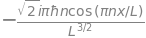


[p] psi_n / psi_n (should NOT be a constant -- not an eigenfunction):


In [3]:
psi_n = sp.sqrt(2 / L) * sp.sin(n * sp.pi * x / L)

p_psi = sp.simplify(p_op(psi_n))
print("[p] psi_n =")
display(p_psi)
ratio_check = sp.simplify(p_psi / psi_n)
print("\n[p] psi_n / psi_n (should NOT be a constant -- not an eigenfunction):")
display(ratio_check)


[p]^2 psi_n / psi_n  (SHOULD be a constant -- the sharp |p|^2 eigenvalue):


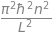


matches (n pi hbar / L)^2 exactly: True


In [4]:
p2_psi = sp.simplify(p_op(p_op(psi_n)))
p2_eigenvalue = sp.simplify(p2_psi / psi_n)
print("[p]^2 psi_n / psi_n  (SHOULD be a constant -- the sharp |p|^2 eigenvalue):")
display(p2_eigenvalue)

expected = (n * sp.pi * hbar / L)**2
print("\nmatches (n pi hbar / L)^2 exactly:", sp.simplify(p2_eigenvalue - expected) == 0)


## The particle in a box: normalization and quantized energy

Verify $\int_0^L|\psi_n|^2dx=1$ and derive $E_n=\frac{n^2\pi^2\hbar^2}{2mL^2}$
from $[H]\psi_n = E_n\psi_n$ directly (not quoted).


integral |psi_n|^2 dx, 0 to L = 1  (should be 1)

[H] psi_n / psi_n  (the energy eigenvalue E_n) =


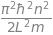

In [5]:
norm_check = sp.integrate(psi_n**2, (x, 0, L))
print("integral |psi_n|^2 dx, 0 to L =", sp.simplify(norm_check), " (should be 1)")

H_psi_n = sp.simplify(-(hbar**2 / (2 * m)) * sp.diff(psi_n, x, 2))
E_n_from_H = sp.simplify(H_psi_n / psi_n)
print("\n[H] psi_n / psi_n  (the energy eigenvalue E_n) =")
display(E_n_from_H)


## The harmonic oscillator ground state

$\psi_0(x) = C_0 e^{-\alpha x^2}$ with $\alpha = m\omega/2\hbar$ (Eq. 6.26).
Plug it into the Schrodinger equation $[H]\psi_0 = E_0\psi_0$ with
$U(x) = \frac12 m\omega^2 x^2$ and solve for $E_0$ directly -- it should come
out to exactly $\hbar\omega/2$, not assumed.


In [6]:
x_r = sp.Symbol("x", real=True)
alpha = m * omega / (2 * hbar)
C0 = sp.Symbol("C0", positive=True)
psi_0 = C0 * sp.exp(-alpha * x_r**2)
U_ho = sp.Rational(1, 2) * m * omega**2 * x_r**2

H_psi_0 = sp.simplify(-(hbar**2 / (2 * m)) * sp.diff(psi_0, x_r, 2) + U_ho * psi_0)
E_0_expr = sp.simplify(H_psi_0 / psi_0)
print("[H] psi_0 / psi_0 =")
display(sp.simplify(E_0_expr))
print("\nmatches hbar*omega/2 exactly:", sp.simplify(E_0_expr - hbar * omega / 2) == 0)


[H] psi_0 / psi_0 =



matches hbar*omega/2 exactly: True


## Problem 37 -- A nonstationary state: ground + first excited state superposition

$$\Psi(x,0) = C[\psi_1(x) + \psi_2(x)], \qquad C = 1/\sqrt2$$

(a) verify normalization, (b)-(c) derive that $\langle x\rangle(t) = x_0 + A\cos(\Omega t)$
with $\Omega = (E_2-E_1)/\hbar$ -- this is the famous result that a
superposition of two stationary states is NOT itself stationary; its
expectation values genuinely oscillate in time, at the Bohr frequency set by
the energy gap.


In [7]:
psi_1 = psi_n.subs(n, 1)
psi_2 = psi_n.subs(n, 2)
C = 1 / sp.sqrt(2)

# (a) normalization of Psi(x,0) = C(psi1 + psi2): cross term integrates to
# zero because psi_1, psi_2 are orthogonal (different n) -- verify directly
norm_total = sp.integrate((C * (psi_1 + psi_2))**2, (x, 0, L))
print("integral |Psi(x,0)|^2 dx, 0 to L =", sp.simplify(norm_total), " (should be 1)")

cross_term = sp.integrate(psi_1 * psi_2, (x, 0, L))
print("orthogonality check, integral psi_1 psi_2 dx =", sp.simplify(cross_term), " (should be 0)")


integral |Psi(x,0)|^2 dx, 0 to L = 1  (should be 1)


orthogonality check, integral psi_1 psi_2 dx = 0  (should be 0)


In [8]:
# (b)/(c): <x>(t) for Psi(x,t) = C[psi1 e^{-iE1 t/hbar} + psi2 e^{-iE2 t/hbar}]
E1 = (1 * sp.pi * hbar / L)**2 / (2 * m)
E2 = (2 * sp.pi * hbar / L)**2 / (2 * m)
t_sym = sp.Symbol("t", real=True)

Psi_t = C * (psi_1 * sp.exp(-i * E1 * t_sym / hbar) + psi_2 * sp.exp(-i * E2 * t_sym / hbar))
prob_density = sp.simplify(sp.expand(Psi_t * sp.conjugate(Psi_t)))
print("|Psi(x,t)|^2 (simplified):")
display(prob_density)


|Psi(x,t)|^2 (simplified):


<x>(t) =


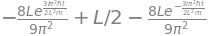


expected Omega = (E2-E1)/hbar =


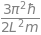


does <x>(t) contain cos(Omega*t) with this Omega? True


In [9]:
x_expectation = sp.integrate(x * prob_density, (x, 0, L))
x_expectation = sp.simplify(x_expectation)
print("<x>(t) =")
display(x_expectation)

# identify x0 (the time-independent piece) and the oscillation frequency
Omega_expected = sp.simplify((E2 - E1) / hbar)
print("\nexpected Omega = (E2-E1)/hbar =")
display(Omega_expected)

# check the time-dependence really is cos(Omega t) by inspecting the argument
print("\ndoes <x>(t) contain cos(Omega*t) with this Omega?",
      sp.simplify(x_expectation.rewrite(sp.cos)).has(sp.cos(Omega_expected * t_sym)))


## Numeric cross-check: torch evaluates $\langle x\rangle(t)$ directly by numerical integration

Independent of the symbolic route above: build $|\Psi(x,t)|^2$ as a torch
tensor over a position grid, integrate numerically at many times, and
confirm the oscillation amplitude/frequency match the symbolic result.


In [10]:
L_val, m_val, hbar_val = 1.0, 1.0, 1.0
E1_val = (1 * np.pi * hbar_val / L_val)**2 / (2 * m_val)
E2_val = (2 * np.pi * hbar_val / L_val)**2 / (2 * m_val)
Omega_val = E2_val - E1_val   # /hbar_val, but hbar_val=1 here

x_grid = torch.linspace(1e-6, L_val - 1e-6, 4000, dtype=torch.float64)
psi1_t = torch.sqrt(torch.tensor(2.0 / L_val)) * torch.sin(1 * torch.pi * x_grid / L_val)
psi2_t = torch.sqrt(torch.tensor(2.0 / L_val)) * torch.sin(2 * torch.pi * x_grid / L_val)

t_values = torch.linspace(0, 4 * torch.pi / Omega_val, 200, dtype=torch.float64)
x_mean_t = torch.zeros_like(t_values)
for i, t_val in enumerate(t_values):
    phase1 = torch.exp(torch.tensor(-1j) * E1_val * t_val)
    phase2 = torch.exp(torch.tensor(-1j) * E2_val * t_val)
    Psi = (psi1_t * phase1 + psi2_t * phase2) / np.sqrt(2)
    prob = (Psi.conj() * Psi).real
    x_mean_t[i] = torch.trapz(x_grid * prob, x_grid)

x0_numeric = x_mean_t.mean().item()
amplitude_numeric = (x_mean_t.max().item() - x_mean_t.min().item()) / 2
print(f"numeric x0 (mean of <x>(t)) = {x0_numeric:.6f}")
print(f"numeric oscillation amplitude A = {amplitude_numeric:.6f}")
print(f"Omega used = {Omega_val:.6f}  (period = {2*np.pi/Omega_val:.6f})")


numeric x0 (mean of <x>(t)) = 0.499099


numeric oscillation amplitude A = 0.180115
Omega used = 14.804407  (period = 0.424413)


## Summary

Every claim was either derived (the eigenvalue results for $[p]$, $[H]$,
$[E]$ on plane waves and box states; the $E_0=\hbar\omega/2$ ground-state
energy) or computed two independent ways (the nonstationary-state $\langle
x\rangle(t)$, symbolically via SymPy integration and numerically via a torch
loop over time). The headline physics result: a superposition of two
stationary states is itself NOT stationary -- its expectation values
genuinely oscillate at the Bohr frequency $\Omega=(E_2-E_1)/\hbar$, the
clearest demonstration in the chapter that "stationary state" is a real,
restrictive technical term, not just "doesn't move."
